# Stochastic Expectation-Maximization

In this notebook, I'll describe and demonstrate an early version of *stochastic expectation maximization* (SEM), a technique that I learned about primarily from [this paper](https://proceedings.neurips.cc/paper_files/paper/2018/hash/aba22f748b1a6dff75bda4fd1ee9fe07-Abstract.html). This framework applies when the joint distribution between latent and observed variables is in an exponential family, which is indeed true in our case. 

### SEM

I implemented the calculation of the basic SEM update. This update consists in performing an EM-like parameter update using a *single* edge and modifying the current estimate accordingly. Suppose that we have a current estimate $\hat{\theta}^{(t)}$ at time $t$, and that in step $t+1$ we get an update $\theta'$. Then, the basic new estimate in the SEM framework is 

$$
\hat{\theta}^{(t+1)}  = (1-\rho^{(t)})\hat{\theta}^{(t)} + \rho^{(t)}\theta'. 
$$

We can think of $\rho^{(t)}$ as a learning rate that tunes how quickly the parameter update occurs. As in other optimization frameworks, it is possible to choose $\rho^{(t)}$ to decrease over time. In the cited paper above, the authors instead take a different approach in which they modify the update in order to make it unnecessary to tune the learning rate. 

### In Our Work

So far, we have implemented SEM and recently implemented minibatch SEM in which the vector of sufficient statistics used to compute the updates is computed from a small set of edges, rather than from an individual one. 

In [1]:
%load_ext autoreload
%autoreload 2

import importlib 
m = importlib.import_module(".model", "src")
sem = importlib.import_module(".sem", "src") # my implementation of baby SEM
em = importlib.import_module(".em", "src")
ll = importlib.import_module(".likelihoods", "src")
from matplotlib import pyplot as plt
import numpy as np

Here's a simple example of our implementation working well. 

In [2]:
# generate some sample data

eta   = 0.7   # node retention in edges
beta  = 1.2   # poisson number of novel nodes
gamma = 0.8   # poisson number of nodes from graph

timesteps = int(1e4)

H = m.GrowingHypergraph()
H.add_edge((0, 1))
H.add_edge((2, 3))

for _ in range(timesteps):
    H.sample_edge(eta, gamma, beta, True)
    
print(f"This hypergraph has {len(H.edge_size_sequence())} edges and {len(H.degree_sequence())} nodes.")

This hypergraph has 10002 edges and 11861 nodes.


In [3]:
# initialize a model with 
# initial parameter guesses

init_pars = {"eta"   : 0.3, 
             "beta"  : 0.7, 
             "gamma" : 0.1}


In [6]:
# track the parameter estimates over time

def experiment(H, steps, ax = None, batch_size = 1, verbose = False):
    
    if not ax: 
        fig, ax = plt.subplots(1, 1)
        
    EM = sem.SEM(H, 
             ll.guaranteed_edge_sample_likelihood,
             ll.nodes_from_hypergraph_likelihood,
             ll.novel_nodes_likelihood,
             pars = init_pars.copy(), 
             memoize = True)
    
    epochs = int(steps / batch_size)
    
    ETA   = np.zeros(epochs)
    BETA  = np.zeros(epochs)
    GAMMA = np.zeros(epochs)

    # main loop
    for i in range(epochs):

        if i % max(int(epochs/20), 1) == 0 and verbose:
            print("--------")
            print(f"Completed epoch {i}")
            print(EM.pars)
            
        EM.SEM_step(0.002*batch_size, batch_size = batch_size) # both the stochastic E and the M steps are in here
        ETA[i] = EM.pars["eta"]
        BETA[i] = EM.pars["beta"]
        GAMMA[i] = EM.pars["gamma"]
        
    # how'd we do?     
    T = np.arange(epochs)
    ax.plot(T, ETA,   label = r"$\hat{\eta}$", color = "blue")
    ax.plot(T, BETA,  label = r"$\hat{\beta}$", color = "black")
    ax.plot(T, GAMMA, label = r"$\hat{\gamma}$", color = "grey")

    ax.plot(T, np.ones((epochs,))*eta, color = "blue", linestyle = "dashed")
    ax.plot(T, np.ones((epochs,))*beta, color = "black", linestyle = "dashed")
    ax.plot(T, np.ones((epochs,))*gamma, color = "grey", linestyle = "dashed")

    ax.set(xlabel = "epoch", ylabel = "parameter estimate")
    ax.legend()

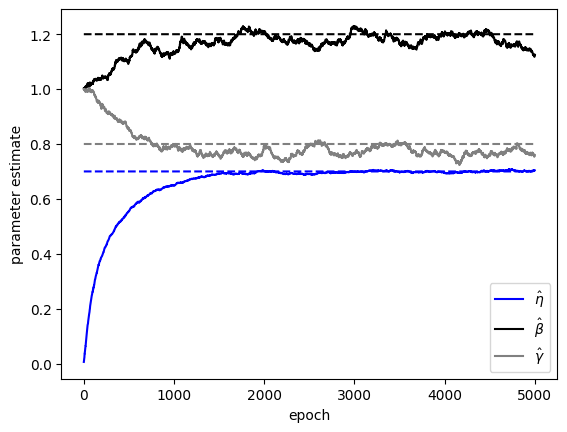

In [8]:
experiment(H, 5000)

The estimates, though noisy, agree well with the true values. 

# Role of Batching

In several previous experiments, we found that stochastic EM had the tendency to underestimate $\eta$ when both $\beta$ and $\gamma$ were small. The specific variant of stochastic EM in which we observed this was batch-size 1: the vector of expected sufficient statistics is formed by sampling a single edge and examining its candidate predecessors. 

In the version of this notebook currently on the `main` branch, the SEM approach is to maintain a moving average of parameter estimates. In this setting, we observe bias in some parameter regimes when using single-edge sampling, but this bias is mitigated when using larger batch sizes for the SEM step. 

This suggested to me that it might be beneficial to maintain a moving average, not of the parameter estimates themselves, but rather of the sufficient statistics, from which the parameters are then estimated. Indeed, as illustrated below, this appears to lead to largely unbiased results even in when using batch-size 1. 

In [9]:
# generate some sample data

eta   = 0.6   # node retention in edges
beta  = 0.3   # poisson number of novel nodes
gamma = 0.2   # poisson number of nodes from graph

timesteps = int(10000)

H = m.GrowingHypergraph()
H.add_edge((0, 1))
H.add_edge((2, 3))

for _ in range(timesteps):
    H.sample_edge(eta, gamma, beta, True)
    
print(f"This hypergraph has {len(H.edge_size_sequence())} edges and {len(H.degree_sequence())} nodes.")


This hypergraph has 10002 edges and 3043 nodes.


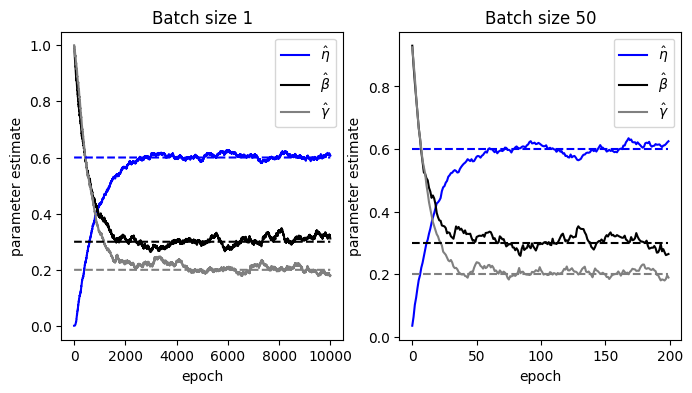

In [10]:
fig, axarr = plt.subplots(1, 2, figsize = (8, 4))
axarr[0].set(title = "Batch size 1")
axarr[1].set(title = "Batch size 50")

experiment(H, 10000, axarr[0], batch_size = 1, verbose = False)
experiment(H, 10000, axarr[1], batch_size = 50, verbose = False)

So, while the bias in the unbatched case may be important to understand, it appears that we can largely avoid it as a practical matter by batching when estimating the vector of sufficient statistics. 